# 1

In [1]:
import os

# gets rid of irritating warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from datasets import load_dataset


df_raw = load_dataset("PolyAI/banking77", trust_remote_code=True)["train"].to_pandas()
df_raw

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11
...,...,...
9998,You provide support in what countries?,24
9999,What countries are you supporting?,24
10000,What countries are getting support?,24
10001,Are cards available in the EU?,24


In [3]:
print("Total data length:", len(df_raw))

Total data length: 10003


In [4]:
print("Data types:")
df_raw.dtypes

Data types:


text     object
label     int64
dtype: object

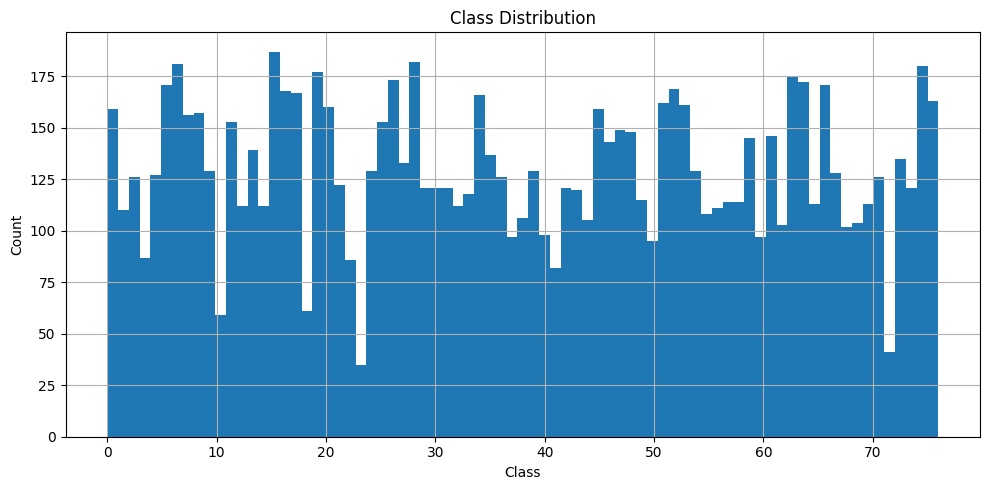

In [5]:
df_raw.hist(bins=77, figsize=(10, 5))
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.tight_layout()
plt.show()

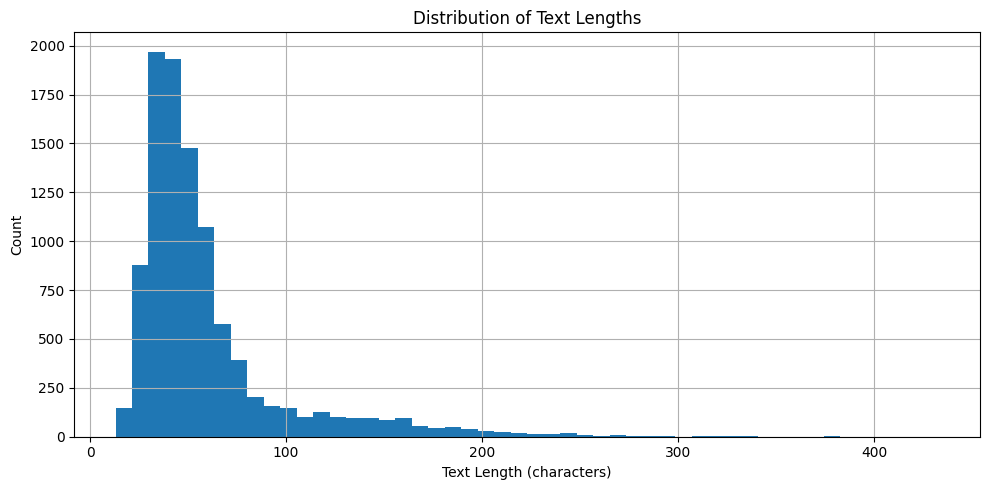

In [6]:
text_lengths = df_raw['text'].str.len()
text_lengths.hist(bins=50, figsize=(10, 5))
plt.xlabel('Text Length (characters)')
plt.ylabel('Count')
plt.title('Distribution of Text Lengths')
plt.tight_layout()
plt.show()


# 2

In [7]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegressionCV


def get_initial_model_data(texts: np.ndarray, labels: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(texts)

    logistic_regression = LogisticRegressionCV(cv=5, class_weight="balanced")
    logistic_regression.fit(embeddings, labels)

    pred_probs = logistic_regression.predict_proba(embeddings)

    return embeddings, pred_probs


In [8]:
texts = df_raw["text"].values
labels = df_raw["label"].values

embeddings, pred_probs = get_initial_model_data(texts, labels)

In [9]:
from cleanlab import Datalab


data_dict = {"texts": texts, "labels": labels}
lab = Datalab(data_dict, label_name="labels", task="classification")
lab.find_issues(pred_probs=pred_probs, features=embeddings)
lab.report()

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 493 issues found in the dataset.
Dataset Information: num_examples: 10003, num_classes: 77

Here is a summary of various issues found in your data:

    issue_type  num_issues
near_duplicate         350
       outlier         131
         label          11
       non_iid           1

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


------------------ near_duplicate issues -------------------

About this issue:
	A (near) duplicate issue refers to two or more examples in
    a dataset that are extremely similar to each other, relative
  

In [10]:
duplicate_issues = lab.get_issues("near_duplicate")
duplicate_issues = duplicate_issues[duplicate_issues["is_near_duplicate_issue"]]
duplicate_issues = duplicate_issues.sort_values(by="near_duplicate_score")

In [11]:
for idx, row in duplicate_issues.head(10).iterrows():
    text = texts[idx]
    neighbors = texts[row["near_duplicate_sets"][:3]]
    print(f"Text: {text}")
    print(f"\tDuplicates: {neighbors}")
    print()

Text: I put the wrong pin too many times and now it is blocked. Can you help me unblock it?
	Duplicates: ['\nI put the wrong pin too many times and now it is blocked. Can you help me unblock it?']

Text: I can't seem to be able to use my card
	Duplicates: ["\nI can't seem to be able to use my card\n\n\n"]

Text: Do I need to go to a physical bank to change my PIN?
	Duplicates: ['\nDo I need to go to a physical bank to change my PIN?']

Text: 
I can't seem to be able to use my card



	Duplicates: ["I can't seem to be able to use my card"]

Text: Why do you keep declining my payment? I tried several times already with this card and it is just not working.
	Duplicates: ['Why do you keep declining my payment?I tried several times already with this card and it is just not working.'
 'Why do you keep declining my payment?I tried several times with this card and it is just not working.']

Text: 
Do I need to go to a physical bank to change my PIN?
	Duplicates: ['Do I need to go to a physical

In [12]:
for idx, row in duplicate_issues.tail(10).iterrows():
    text = texts[idx]
    neighbors = texts[row["near_duplicate_sets"][:3]]
    print(f"Text: {text}")
    print(f"\tDuplicates: {neighbors}")
    print()

Text: What do I do if I can't prove my identity?
	Duplicates: ["What should I do if I can't prove my identity."]

Text: How can I receive a virtual card?
	Duplicates: ['How do I receive a virtual card?']

Text: How do I receive a virtual card?
	Duplicates: ['How can I receive a virtual card?']

Text: Can you please tell me why my transfer failed?
	Duplicates: ['Can you please explain why my transfer failed?']

Text: Can you please explain why my transfer failed?
	Duplicates: ['Can you please tell me why my transfer failed?']

Text: Is there a limit to using a disposable virtual card?
	Duplicates: ['Is there a limit to a disposable virtual card?']

Text: Is there a limit to a disposable virtual card?
	Duplicates: ['Is there a limit to using a disposable virtual card?']

Text: Can I top up any amount?
	Duplicates: ['Can I top-up any amount?']

Text: Can I top-up any amount?
	Duplicates: ['Can I top up any amount?']

Text: How long will a transfer from the US take?
	Duplicates: ['How long

In [13]:
df_raw["text_lower"] = df_raw["text"].str.lower().str.strip()
df_deduplicated = df_raw.drop_duplicates(subset="text_lower")
df_deduplicated = df_deduplicated.drop(columns="text_lower")
df_deduplicated = df_deduplicated.reset_index(drop=True)
df_deduplicated

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11
...,...,...
9994,You provide support in what countries?,24
9995,What countries are you supporting?,24
9996,What countries are getting support?,24
9997,Are cards available in the EU?,24


In [14]:
label_issues = lab.get_issues("label")
label_issues = label_issues[label_issues["is_label_issue"]]
label_issues = label_issues.sort_values(by="label_score")

top_label_issues_y_true = label_issues.head(10)["given_label"]
top_label_issues_y_pred = label_issues.head(10)["predicted_label"]
top_label_issues_idxs = label_issues.head(10).index
top_label_issues_texts = texts[top_label_issues_idxs]

print("Top 10 label issues")
for text, y_true, y_pred in zip(top_label_issues_texts, top_label_issues_y_true, top_label_issues_y_pred):
    print(f"y_true {y_true}, y_pred {y_pred}, text: {text}")
    print()

Top 10 label issues
y_true 5, y_pred 48, text: My transfer is pending too long.

y_true 49, y_pred 38, text: Where do I find PIN for my card?

y_true 27, y_pred 25, text: Why did my payment get declined?

y_true 28, y_pred 16, text: There is a payment I don't recognise!

y_true 5, y_pred 67, text: How long does it take for money to reach my account?

y_true 65, y_pred 54, text: What currencies can I use to top up my account?

y_true 59, y_pred 61, text: Looks like my top-up has been cancelled

y_true 48, y_pred 5, text: I have not seen any changes in my account balance(s) after making a transfer.

y_true 11, y_pred 12, text: How long will it take for me to get my card?

y_true 5, y_pred 67, text: How long does it take for money to transfer?



In [15]:
# make sure we don't get key errors - we removed some rows earlier during deduplication
label_issues = label_issues[label_issues.index.isin(df_deduplicated.index)]

idxs = label_issues.index.tolist()
pred_labels = label_issues["predicted_label"]

df_fixed = df_deduplicated.copy()
df_fixed.loc[idxs, "label"] = pred_labels
df_fixed

,text,label
0,I am still waiting on my card?,11
1,What can I do if my card still hasn't arrived ...,11
2,I have been waiting over a week. Is the card s...,11
3,Can I track my card while it is in the process...,11
4,"How do I know if I will get my card, or if it ...",11
...,...,...
9994,You provide support in what countries?,24
9995,What countries are you supporting?,24
9996,What countries are getting support?,24
9997,Are cards available in the EU?,24


In [16]:
outlier_issues = lab.get_issues("outlier")
outlier_issues = outlier_issues[outlier_issues["is_outlier_issue"]]
outlier_issues = outlier_issues.sort_values(by="outlier_score")

for idx, row in outlier_issues.head(10).iterrows():
    text = texts[idx]
    score = row["outlier_score"]
    label = labels[idx]
    pred_label = pred_probs[idx].argmax()
    print(f"Score: {score:.4f}")
    print(f"Text: {text}")
    print(f"Label: {label}")
    print(f"Predicted Label: {pred_label}")
    print()

Score: 0.0051
Text: WHAT IS THE ATMOSPHERE OF IT
Label: 10
Predicted Label: 10

Score: 0.0063
Text: what is the word?
Label: 28
Predicted Label: 28

Score: 0.0079
Text: What is this witdrawal
Label: 20
Predicted Label: 20

Score: 0.0079
Text: what is the matter?
Label: 28
Predicted Label: 28

Score: 0.0087
Text: WHAT IS THE SOLUTION OF THIS PROBLEM
Label: 11
Predicted Label: 11

Score: 0.0107
Text: I prefer Mastecard.
Label: 73
Predicted Label: 73

Score: 0.0164
Text: I have made 5 attempts to make a very standard survey, yet I can't get it to work. What is the problem? Is there an issue related to your system?
Label: 35
Predicted Label: 35

Score: 0.0167
Text: WHAT IS THE MAIN REASON OF THIS PROBLEM
Label: 14
Predicted Label: 14

Score: 0.0168
Text: WHAT IS THE REASON FOR THAT
Label: 14
Predicted Label: 14

Score: 0.0189
Text: why was i chargged
Label: 64
Predicted Label: 64



My results agree with [the paper](https://aclanthology.org/2022.insights-1.19/) pointing out the label quality issues.
Only labels problems are worth fixing, as near-duplicates are rare and outliers are not that suspicious.

# 3 & 4

In [17]:
import torch
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split


test_size = int(0.2 * len(df_fixed))
train_size = int(0.8 * len(df_fixed))

df_train, df_valid = train_test_split(df_fixed, train_size=train_size, random_state=0, stratify=df_fixed["label"])

datasets_dict = DatasetDict()
datasets_dict["train"] = Dataset.from_pandas(df_train, split="train")
datasets_dict["valid"] = Dataset.from_pandas(df_valid, split="valid")
datasets_dict["test"] = Dataset.from_pandas(load_dataset("PolyAI/banking77", trust_remote_code=True)["test"].to_pandas())

In [18]:
import joblib
from transformers import AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")


def tokenize(examples: dict) -> dict:
    encoded_examples = tokenizer(examples["text"], padding=True, truncation=True)
    encoded_examples["label"] = examples["label"]
    return encoded_examples


num_cores = joblib.cpu_count(only_physical_cores=True)
datasets_tokenized = datasets_dict.map(tokenize, batched=True)

Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3080 [00:00<?, ? examples/s]

In [26]:
import os
import random

from sklearn.metrics import f1_score
from transformers import AutoModelForSequenceClassification, EvalPrediction, Trainer, TrainingArguments


# set determinism settings
os.environ["PYTHONHASHSEED"] = str(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", num_labels=77)


# freeze some weights to speed up training
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False

for param in model.distilbert.transformer.parameters():
    param.requires_grad = False


def compute_metrics(eval_pred: EvalPrediction) -> dict:
    y_true = eval_pred.label_ids
    logits = eval_pred.predictions
    y_pred = np.argmax(logits, axis=1)
    f1 = f1_score(y_true, y_pred, average='macro')
    return {"f1": f1}


training_args = TrainingArguments(
    output_dir="finetuned_model",
    # change num_train_epochs depending on your hardware
    # if lower, increase learning rate and decrease save_steps and eval_steps
    learning_rate=2e-3,
    num_train_epochs=100,
    eval_strategy="steps",
    save_steps=10000,
    eval_steps=10000,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    seed=0,
    data_seed=0,
    fp16=True,  # comment this out if you have unsupported hardware
    dataloader_num_workers=1,  # comment out if necessary
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=datasets_tokenized["train"],
    eval_dataset=datasets_tokenized["valid"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Step,Training Loss,Validation Loss,F1
10000,1.728400,1.171151,0.640636
20000,1.476600,0.956250,0.721818
30000,1.410600,0.919167,0.712348
40000,1.296800,0.815274,0.766188
50000,1.257900,0.802714,0.772400
60000,1.184200,0.738556,0.794294
70000,1.176200,0.704853,0.797446
80000,1.157900,0.693351,0.805784
90000,1.058100,0.671727,0.817001
100000,1.028400,0.666179,0.817413


TrainOutput(global_step=100000, training_loss=1.3441484906005858, metrics={'train_runtime': 1141.1154, 'train_samples_per_second': 700.981, 'train_steps_per_second': 87.634, 'total_flos': 1.9808617952837716e+16, 'train_loss': 1.3441484906005858, 'epoch': 100.0})

Precision: 83.07%
Recall: 82.24%
F1-score: 82.21%
AUROC: 99.58%
MCC: 82.02%


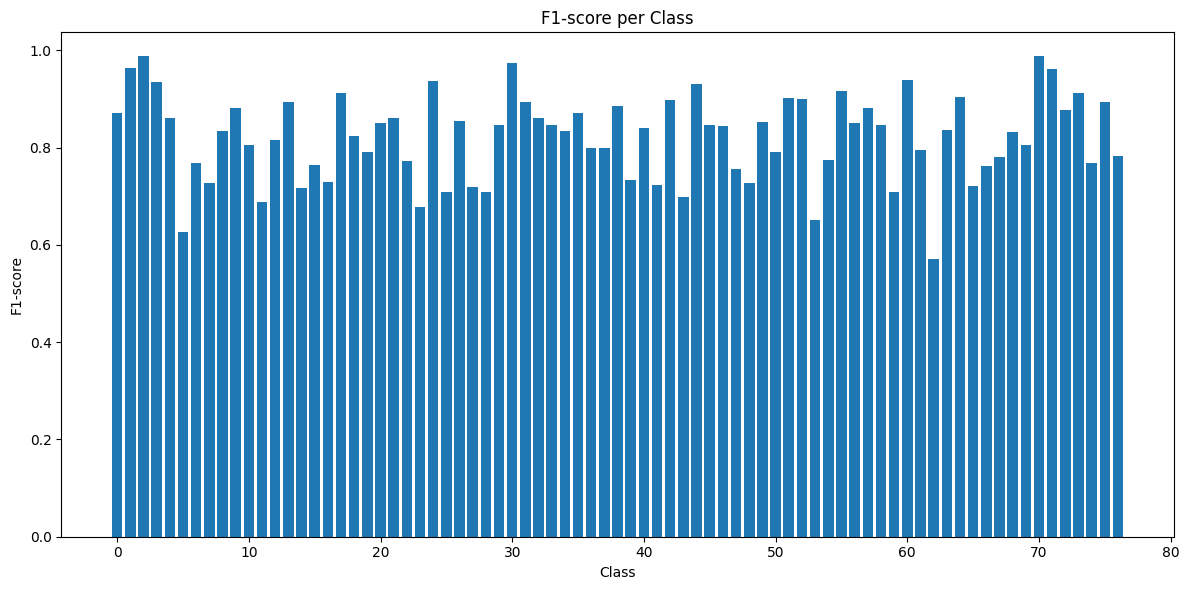

In [27]:
from torch import softmax
from sklearn.metrics import f1_score, matthews_corrcoef, precision_score, recall_score, roc_auc_score


pred_output = trainer.predict(datasets_tokenized["test"])
logits = torch.from_numpy(pred_output.predictions)
y_pred = np.argmax(logits, axis=1)
y_test = datasets_tokenized["test"]["label"]

probs = softmax(logits, dim=1).numpy()

print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.2%}")
print(f"Recall: {recall_score(y_test, y_pred, average='macro'):.2%}")
print(f"F1-score: {f1_score(y_test, y_pred, average='macro'):.2%}")
print(f"AUROC: {roc_auc_score(y_test, probs, multi_class='ovo'):.2%}")
print(f"MCC: {matthews_corrcoef(y_test, y_pred):.2%}")

f1_per_class = f1_score(y_test, y_pred, average=None)

plt.figure(figsize=(12, 6))
plt.bar(range(77), f1_per_class)
plt.xlabel('Class')
plt.ylabel('F1-score')
plt.title('F1-score per Class')
plt.tight_layout()
plt.show()

F1-score is about 10 percentage points lower than the one reported in the paper. This may be due to too few training epochs. As we can see from training logs, the model was still improving at the end of training. Bigger number of epochs would likely help. From my perspective results are still good, considering that we fixed some labels only partially and did not do any hyperparameter tuning. There are some classes with F1-score about 0.6, and there are classes with F1-score close to 1.0.

# 5

In [28]:
df_test = load_dataset("PolyAI/banking77", trust_remote_code=True)["test"].to_pandas()

In [29]:
from giskard import Model as GiskardModel, Dataset as GiskardDataset, scan, testing
from transformers import pipeline

df_test = load_dataset("PolyAI/banking77", trust_remote_code=True)["test"].to_pandas()

trained_model = trainer.model
trained_model.eval()
model_pipeline = pipeline(
    "text-classification",
    model=trained_model,
    tokenizer=tokenizer,
    top_k=None,
    device="cuda" if torch.cuda.is_available() else "cpu",
)


@torch.no_grad()
def prediction_function(df: pd.DataFrame) -> np.ndarray:
    pred_output = model_pipeline(df["text"].tolist())
    y_pred_proba = np.zeros((len(pred_output), 77))
    for i, preds in enumerate(pred_output):
        for pred in preds:
            label_idx = int(pred["label"].split("_")[-1])
            y_pred_proba[i, label_idx] = pred["score"]
    return y_pred_proba


giskard_dataset = GiskardDataset(df_test, target="label")

giskard_model = GiskardModel(
    model=prediction_function,
    model_type="classification",
    classification_labels=list(range(77)),
    feature_names=["text"],
)
scan_results = scan(giskard_model, giskard_dataset, verbose=False)
display(scan_results)

Device set to use cuda


2025-11-23 20:00:27,813 pid:403643 MainThread giskard.datasets.base INFO     Your 'pandas.DataFrame' is successfully wrapped by Giskard's 'Dataset' wrapper class.
2025-11-23 20:00:27,815 pid:403643 MainThread giskard.models.automodel INFO     Your 'prediction_function' is successfully wrapped by Giskard's 'PredictionFunctionModel' wrapper class.
2025-11-23 20:00:27,842 pid:403643 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-23 20:00:27,974 pid:403643 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (10, 2) executed in 0:00:00.146382
2025-11-23 20:00:27,982 pid:403643 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-23 20:00:27,990 pid:403643 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (1, 2) executed in 0:00:00.013511
2025-11-23 20:00:27,997 pid:403643 MainThread giskard.dataset

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


2025-11-23 20:01:49,403 pid:403643 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (1000, 2) executed in 0:00:04.772972
2025-11-23 20:01:49,404 pid:403643 MainThread giskard.scanner.logger INFO     TextPerturbationDetector: Testing `text` for perturbation `Add typos`	Fail rate: 0.470
2025-11-23 20:01:49,454 pid:403643 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-23 20:01:49,457 pid:403643 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (1000, 2) executed in 0:00:00.008824
2025-11-23 20:01:49,464 pid:403643 MainThread giskard.datasets.base INFO     Casting dataframe columns from {'text': 'object'} to {'text': 'object'}
2025-11-23 20:01:54,215 pid:403643 MainThread giskard.utils.logging_utils INFO     Predicted dataset with shape (1000, 2) executed in 0:00:04.756821
2025-11-23 20:01:54,216 pid:403643 MainThread giskard.scanner.logger INFO     TextPerturba

<iframe id="scan-23399488008848" srcdoc="<!doctype html>
<html lang="en">

<head>
 <title>Giskard Scan Results</title>
 <base target="_blank">
 <meta charset="utf-8">
 
<style>pre code.hljs{display:block;overflow-x:auto;padding:1em}code.hljs{padding:3px 5px}
/*!
 Theme: GitHub Dark
 Description: Dark theme as seen on github.com
 Author: github.com
 Maintainer: @Hirse
 Updated: 2021-05-15

 Outdated base version: https://github.com/primer/github-syntax-dark
 Current colors taken from GitHub's CSS
*/.hljs{background:#0d1117;color:#c9d1d9}.hljs-doctag,.hljs-keyword,.hljs-meta .hljs-keyword,.hljs-template-tag,.hljs-template-variable,.hljs-type,.hljs-variable.language_{color:#ff7b72}.hljs-title,.hljs-title.class_,.hljs-title.class_.inherited__,.hljs-title.function_{color:#d2a8ff}.hljs-attr,.hljs-attribute,.hljs-literal,.hljs-meta,.hljs-number,.hljs-operator,.hljs-selector-attr,.hljs-selector-class,.hljs-selector-id,.hljs-variable{color:#79c0ff}.hljs-meta .hljs-string,.hljs-regexp,.hljs-string{color:#a5d6ff}.hljs-built_in,.hljs-symbol{color:#ffa657}.hljs-code,.hljs-comment,.hljs-formula{color:#8b949e}.hljs-name,.hljs-quote,.hljs-selector-pseudo,.hljs-selector-tag{color:#7ee787}.hljs-subst{color:#c9d1d9}.hljs-section{color:#1f6feb;font-weight:700}.hljs-bullet{color:#f2cc60}.hljs-emphasis{color:#c9d1d9;font-style:italic}.hljs-strong{color:#c9d1d9;font-weight:700}.hljs-addition{background-color:#033a16;color:#aff5b4}.hljs-deletion{background-color:#67060c;color:#ffdcd7}.hljs-copy-wrapper{overflow:hidden;position:relative}.hljs-copy-button:focus,.hljs-copy-wrapper:hover .hljs-copy-button{transform:translateX(0)}.hljs-copy-button{background-color:#2d2b57;background-color:var(--hljs-theme-background);background-image:url('data:image/svg+xml;charset=utf-8,<svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" fill="none" viewBox="0 0 24 24"><path fill="%23fff" fill-rule="evenodd" d="M6 5a1 1 0 0 0-1 1v14a1 1 0 0 0 1 1h12a1 1 0 0 0 1-1V6a1 1 0 0 0-1-1h-2a1 1 0 1 1 0-2h2a3 3 0 0 1 3 3v14a3 3 0 0 1-3 3H6a3 3 0 0 1-3-3V6a3 3 0 0 1 3-3h2a1 1 0 0 1 0 2H6Z" clip-rule="evenodd"/><path fill="%23fff" fill-rule="evenodd" d="M7 3a2 2 0 0 1 2-2h6a2 2 0 0 1 2 2v2a2 2 0 0 1-2 2H9a2 2 0 0 1-2-2V3Zm8 0H9v2h6V3Z" clip-rule="evenodd"/></svg>');background-position:50%;background-repeat:no-repeat;border:1px solid #ffffff22;border-radius:.25rem;color:#fff;height:2rem;position:absolute;right:1em;text-indent:-9999px;top:1em;transition:background-color .2s ease,transform .2s ease-out;width:2rem}.hljs-copy-button:hover{border-color:#ffffff44}.hljs-copy-button:active{border-color:#ffffff66}.hljs-copy-button[data-copied=true]{background-image:none;text-indent:0;width:auto}@media (prefers-reduced-motion){.hljs-copy-button{transition:none}}.hljs-copy-alert{clip:rect(0 0 0 0);-webkit-clip-path:inset(50%);clip-path:inset(50%);height:1px;overflow:hidden;position:absolute;white-space:nowrap;width:1px}
/*! tailwindcss v3.3.2 | MIT License | https://tailwindcss.com*/*,:after,:before{border:0 solid #e5e7eb;box-sizing:border-box}:after,:before{--tw-content:""}html{-webkit-text-size-adjust:100%;font-feature-settings:normal;font-family:ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji;font-variation-settings:normal;line-height:1.5;-moz-tab-size:4;-o-tab-size:4;tab-size:4}body{line-height:inherit;margin:0}hr{border-top-width:1px;color:inherit;height:0}abbr:where([title]){-webkit-text-decoration:underline dotted;text-decoration:underline dotted}h1,h2,h3,h4,h5,h6{font-size:inherit;font-weight:inherit}a{color:inherit;text-decoration:inherit}b,strong{font-weight:bolder}code,kbd,pre,samp{font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,Liberation Mono,Courier New,monospace;font-size:1em}small{font-size:80%}sub,sup{font-size:75%;line-height:0;position:relative;vertical-align:baseline}sub{bottom:-.25em}sup{top:-.5em}table{border-collapse

In [30]:
display(scan_results)

<iframe id="scan-23399374132880" srcdoc="<!doctype html>
<html lang="en">

<head>
 <title>Giskard Scan Results</title>
 <base target="_blank">
 <meta charset="utf-8">
 
<style>pre code.hljs{display:block;overflow-x:auto;padding:1em}code.hljs{padding:3px 5px}
/*!
 Theme: GitHub Dark
 Description: Dark theme as seen on github.com
 Author: github.com
 Maintainer: @Hirse
 Updated: 2021-05-15

 Outdated base version: https://github.com/primer/github-syntax-dark
 Current colors taken from GitHub's CSS
*/.hljs{background:#0d1117;color:#c9d1d9}.hljs-doctag,.hljs-keyword,.hljs-meta .hljs-keyword,.hljs-template-tag,.hljs-template-variable,.hljs-type,.hljs-variable.language_{color:#ff7b72}.hljs-title,.hljs-title.class_,.hljs-title.class_.inherited__,.hljs-title.function_{color:#d2a8ff}.hljs-attr,.hljs-attribute,.hljs-literal,.hljs-meta,.hljs-number,.hljs-operator,.hljs-selector-attr,.hljs-selector-class,.hljs-selector-id,.hljs-variable{color:#79c0ff}.hljs-meta .hljs-string,.hljs-regexp,.hljs-string{color:#a5d6ff}.hljs-built_in,.hljs-symbol{color:#ffa657}.hljs-code,.hljs-comment,.hljs-formula{color:#8b949e}.hljs-name,.hljs-quote,.hljs-selector-pseudo,.hljs-selector-tag{color:#7ee787}.hljs-subst{color:#c9d1d9}.hljs-section{color:#1f6feb;font-weight:700}.hljs-bullet{color:#f2cc60}.hljs-emphasis{color:#c9d1d9;font-style:italic}.hljs-strong{color:#c9d1d9;font-weight:700}.hljs-addition{background-color:#033a16;color:#aff5b4}.hljs-deletion{background-color:#67060c;color:#ffdcd7}.hljs-copy-wrapper{overflow:hidden;position:relative}.hljs-copy-button:focus,.hljs-copy-wrapper:hover .hljs-copy-button{transform:translateX(0)}.hljs-copy-button{background-color:#2d2b57;background-color:var(--hljs-theme-background);background-image:url('data:image/svg+xml;charset=utf-8,<svg xmlns="http://www.w3.org/2000/svg" width="16" height="16" fill="none" viewBox="0 0 24 24"><path fill="%23fff" fill-rule="evenodd" d="M6 5a1 1 0 0 0-1 1v14a1 1 0 0 0 1 1h12a1 1 0 0 0 1-1V6a1 1 0 0 0-1-1h-2a1 1 0 1 1 0-2h2a3 3 0 0 1 3 3v14a3 3 0 0 1-3 3H6a3 3 0 0 1-3-3V6a3 3 0 0 1 3-3h2a1 1 0 0 1 0 2H6Z" clip-rule="evenodd"/><path fill="%23fff" fill-rule="evenodd" d="M7 3a2 2 0 0 1 2-2h6a2 2 0 0 1 2 2v2a2 2 0 0 1-2 2H9a2 2 0 0 1-2-2V3Zm8 0H9v2h6V3Z" clip-rule="evenodd"/></svg>');background-position:50%;background-repeat:no-repeat;border:1px solid #ffffff22;border-radius:.25rem;color:#fff;height:2rem;position:absolute;right:1em;text-indent:-9999px;top:1em;transition:background-color .2s ease,transform .2s ease-out;width:2rem}.hljs-copy-button:hover{border-color:#ffffff44}.hljs-copy-button:active{border-color:#ffffff66}.hljs-copy-button[data-copied=true]{background-image:none;text-indent:0;width:auto}@media (prefers-reduced-motion){.hljs-copy-button{transition:none}}.hljs-copy-alert{clip:rect(0 0 0 0);-webkit-clip-path:inset(50%);clip-path:inset(50%);height:1px;overflow:hidden;position:absolute;white-space:nowrap;width:1px}
/*! tailwindcss v3.3.2 | MIT License | https://tailwindcss.com*/*,:after,:before{border:0 solid #e5e7eb;box-sizing:border-box}:after,:before{--tw-content:""}html{-webkit-text-size-adjust:100%;font-feature-settings:normal;font-family:ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,Segoe UI,Roboto,Helvetica Neue,Arial,Noto Sans,sans-serif,Apple Color Emoji,Segoe UI Emoji,Segoe UI Symbol,Noto Color Emoji;font-variation-settings:normal;line-height:1.5;-moz-tab-size:4;-o-tab-size:4;tab-size:4}body{line-height:inherit;margin:0}hr{border-top-width:1px;color:inherit;height:0}abbr:where([title]){-webkit-text-decoration:underline dotted;text-decoration:underline dotted}h1,h2,h3,h4,h5,h6{font-size:inherit;font-weight:inherit}a{color:inherit;text-decoration:inherit}b,strong{font-weight:bolder}code,kbd,pre,samp{font-family:ui-monospace,SFMono-Regular,Menlo,Monaco,Consolas,Liberation Mono,Courier New,monospace;font-size:1em}small{font-size:80%}sub,sup{font-size:75%;line-height:0;position:relative;vertical-align:baseline}sub{bottom:-.25em}sup{top:-.5em}table{border-collapse

There is a few potential issues, mostly related to unclear class boundaries. Overall, the model seems to perform well on the test set.

# 6

In [31]:
from copy import deepcopy

from captum.attr import InputXGradient, configure_interpretable_embedding_layer
from captum.attr import visualization as vis


class BERTModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, inputs, attention_mask):
        return self.model(inputs, attention_mask=attention_mask)[0]


def explain_text(model, text: str, y_true: int) -> None:
    for param in model.distilbert.parameters():
        param.requires_grad = True

    tokenizer_output = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
        return_tensors="pt",
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer_output = tokenizer_output.to(device)
    tokens = tokenizer.convert_ids_to_tokens(tokenizer_output["input_ids"][0])

    model_copy = deepcopy(model)
    interpretable_embedding_layer = configure_interpretable_embedding_layer(
        model_copy, "distilbert.embeddings"
    )
    input_embeddings = interpretable_embedding_layer.indices_to_embeddings(
        tokenizer_output["input_ids"]
    )

    model_wrapper = BERTModelWrapper(model_copy)
    input_x_gradient = InputXGradient(model_wrapper)

    with torch.no_grad():
        logits = model(**tokenizer_output).logits
        y_pred = logits.argmax(dim=1).item()
        probs = softmax(logits, dim=1)[0]
        y_pred_proba = probs[y_pred].item()

    attributions = input_x_gradient.attribute(
        input_embeddings,
        target=y_pred,
        additional_forward_args=tokenizer_output["attention_mask"],
    )

    # mean normalization
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    attributions = list([float(attr) for attr in attributions])

    # remove [CLS] and [SEP] tokens
    attributions = attributions[1:-1]
    tokens = tokens[1:-1]

    vis_record = vis.VisualizationDataRecord(
        word_attributions=attributions,
        pred_prob=y_pred_proba,
        pred_class=y_pred,
        true_class=y_true,
        attr_class=y_pred,
        attr_score=sum(attributions),
        raw_input_ids=tokens,
        convergence_score=0,
    )
    vis.visualize_text([vis_record])


In [32]:
# Select samples from different classes
sample_classes = [0, 1, 5, 10, 20, 50]
for cls in sample_classes:
    sample = df_test[df_test["label"] == cls].head(1)
    if not sample.empty:
        text = sample.iloc[0]["text"]
        y_true = sample.iloc[0]["label"]
        print(f"Class {cls}: {text}\n")
        explain_text(trained_model, text, y_true)
        print("\n" + "="*80 + "\n")

Class 0: Could you please activate my card



True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
0,0 (0.98),0,1.25,could you please activate my card




Class 1: how old do i need to be to get an account for myself



True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
1,1 (0.93),1,0.28,how old do i need to be to get an account for myself




Class 5: I made a transfer a few hours ago from a UK banking account.  I do not yet see the transfer.  Please check on this for me.



...

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
10,24 (0.45),24,0.69,will my card be accepted all over the world ?




Class 20: Think someone has took money out with my card. What shall I do?



True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
20,41 (0.39),41,0.49,think someone has took money out with my card . what shall i do ?




Class 50: Will salary be received through this?



True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
50,50 (0.72),50,-0.74,will salary be received through this ?


Due to high number of classes it is difficult to say if model focuses on correct words in all cases. However, from the selected examples it seems that the model is able to identify important words that contribute to the final prediction. In some cases it focuses on multiple words that together define the intent, while in other cases it focuses on single keywords. Overall, the explanations seem reasonable and indicate that the model is making predictions based on relevant parts of the input text.